### Agent-Lab: Multi-Agent -> Voice Assistant

Objective of this notebook is evaluating and adapting a [Multi-Agent Supervisor Architecture](https://langchain-ai.github.io/langgraph/concepts/multi_agent/#supervisor) with coordinator and execution planning steps.

---


In [1]:
%%capture
import json
import os
import nest_asyncio
from IPython.display import Markdown, display, Audio
from dotenv import load_dotenv
from notebooks import experiment_utils
from agent_lab.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = experiment_utils.bootstrap_container([__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

---
### Upload Audio Attachment

In [2]:
# create attachment
file_path = "tests/integration/voice_memos_01_pt_BR.mp3"
attachment_id = experiment_utils.create_attachment(
    file_path=file_path, content_type="audio/mp3"
)
display(Audio(file_path))

---
### OpenAI Voice Assistant

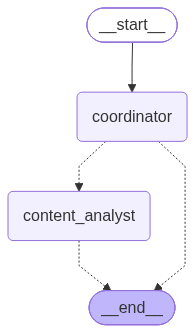

In [3]:
# Create Workflow
openai_agent = experiment_utils.create_openai_agent(
    agent_type="fast_voice_memos", llm_tag="gpt-5-nano", api_key=os.getenv("OPENAI_API_KEY")
)
openai_voice_assistant = container.agent_registry().get_agent("fast_voice_memos")
openai_workflow_builder = openai_voice_assistant.get_workflow_builder(openai_agent["id"])
openai_workflow = openai_workflow_builder.compile(checkpointer=checkpointer)
experiment_utils.print_graph(openai_workflow)

In [4]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Analyse the given audio.",
    agent_id=openai_agent["id"],
    attachment_id=attachment_id,
)

inputs = openai_voice_assistant.get_input_params(message, schema="public")
config = openai_voice_assistant.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_voice_assistant.format_response(result)

In [5]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

**Main Topic**: Reunião sobre o desenvolvimento do projeto Agente X, atraso e necessidade de acelerar, com alinhamento para atualização na próxima reunião.

**Discussed points**:
- Reunião hoje às 11h com Aline da equipe de marketing.
- Projeto Agente X.
- O projeto está atrasado e é necessário acelerar o desenvolvimento.
- Equipe de vendas está preocupada com o prazo de entrega.
- Precisamos apresentar uma atualização na próxima reunião, que será na semana que vem.

**Decisions taken**:
- Acelerar o desenvolvimento do projeto Agente X.
- Apresentar uma atualização do projeto na próxima reunião (semana que vem).

**Next steps**:
- Preparar a atualização de status do projeto Agente X para a próxima reunião.
- Coordenar com Aline da equipe de marketing para acelerar as atividades de desenvolvimento.
- Reavaliar prazos e comunicar envolvimentos relevantes.

**Action points**:
- Aline (equipe de marketing): colaborar para acelerar o desenvolvimento e fornecer dados para a atualização.
- Liderança/Equipe de desenvolvimento: revisar sprint/cronograma para reduzir atrasos e consolidar itens críticos.
- [Responsável pelo projeto Agente X]: compilar status, riscos e previsão de entrega para a apresentação na próxima reunião.
- Comunicar à equipe de vendas sobre o status e expectativas de entrega.

**Named entities**:
- Pessoa: Aline (da equipe de marketing)
- Organizações/grupos: equipe de marketing, equipe de vendas
- Projeto: Agente X